In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
import urllib.request
import zipfile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


In [2]:
# Tải tập dữ liệu CamVid rút gọn (11 class chuẩn + 1 void class)
DATA_URL = "https://s3.amazonaws.com/fast-ai-imagelocal/camvid.tgz"
DATA_DIR = "./camvid"

if not os.path.exists(DATA_DIR):
    import tarfile
    print("Đang tải dữ liệu CamVid...")
    urllib.request.urlretrieve(DATA_URL, "camvid.tgz")
    with tarfile.open("camvid.tgz", "r:gz") as tar:
        tar.extractall(path="./")
    print("Giải nén hoàn tất.")

# Danh mục 11 nhãn đối tượng + class void (255)
CAMVID_CLASSES = [
    'Sky', 'Building', 'Pole', 'Road', 'Pavement',
    'Tree', 'SignSymbol', 'Fence', 'Car', 'Pedestrian', 'Bicyclist', 'Void'
]
NUM_CLASSES = 11
IGNORE_INDEX = 255  # Pixel viền hoặc không xác định

Đang tải dữ liệu CamVid...


/tmp/ipykernel_1590/4165362937.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="./")


Giải nén hoàn tất.


In [19]:
from torchvision.transforms import InterpolationMode, RandomCrop

class CamVidDataset(Dataset):
    def __init__(self, img_dir, mask_dir, crop_size=(352, 480), is_train=True):
        self.img_paths = sorted(glob.glob(os.path.join(img_dir, "*.png")))
        self.mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.png")))
        self.crop_size = crop_size
        self.is_train = is_train

        # Chuẩn hóa ImageNet
        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        image = Image.open(self.img_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx])

        # Synchronized Data Augmentation
        if self.is_train:
            # Resize nhẹ trước khi crop
            image = TF.resize(image, (360, 480))
            mask = TF.resize(mask, (360, 480), interpolation=InterpolationMode.NEAREST)

            # Random Horizontal Flip
            if torch.rand(1).item() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # SỬA TẠI ĐÂY: Dùng trực tiếp RandomCrop.get_params
            i, j, h, w = RandomCrop.get_params(image, output_size=self.crop_size)
            image = TF.crop(image, i, j, h, w)
            mask = TF.crop(mask, i, j, h, w)
        else:
            image = TF.resize(image, self.crop_size)
            mask = TF.resize(mask, self.crop_size, interpolation=InterpolationMode.NEAREST)

        # Chuyển đổi định dạng Tensor & Chuẩn hóa
        image_tensor = TF.to_tensor(image)
        image_tensor = TF.normalize(image_tensor, mean=self.mean, std=self.std)
        mask_tensor = torch.from_numpy(np.array(mask)).long()

        # Đặt các pixel có giá trị >= NUM_CLASSES về IGNORE_INDEX
        mask_tensor[mask_tensor >= NUM_CLASSES] = IGNORE_INDEX

        return image_tensor, mask_tensor

# Tạo lại DataLoader
train_dataset = CamVidDataset(
    img_dir="camvid/images", mask_dir="camvid/labels", is_train=True
)
val_dataset = CamVidDataset(
    img_dir="camvid/images", mask_dir="camvid/labels", is_train=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [20]:
class FCN32s(nn.Module):
    def __init__(self, num_classes=11):
        super(FCN32s, self).__init__()
        vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        self.features = vgg16.features  # Downsample 32x qua 5 lớp MaxPool

        # Convolutionalization: Biến đổi FC layer thành Conv 1x1
        self.head = nn.Sequential(
            nn.Conv2d(512, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.5),
            nn.Conv2d(4096, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.5),
            nn.Conv2d(4096, num_classes, kernel_size=1)
        )
        # Upsample 32x
        self.upsample = nn.ConvTranspose2d(
            num_classes, num_classes, kernel_size=64, stride=32, padding=16, bias=False
        )

    def forward(self, x):
        feat = self.features(x)
        score = self.head(feat)
        out = self.upsample(score)
        return out


class FCN8s(nn.Module):
    def __init__(self, num_classes=11):
        super(FCN8s, self).__init__()
        vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        feats = list(vgg16.features.children())

        # Tách Backbone thành 3 block để trích xuất đặc trưng đa độ phân giải
        self.stage1_pool3 = nn.Sequential(*feats[:17])   # 1/8 resolution, 256 channels
        self.stage2_pool4 = nn.Sequential(*feats[17:24])  # 1/16 resolution, 512 channels
        self.stage3_pool5 = nn.Sequential(*feats[24:])   # 1/32 resolution, 512 channels

        # Convolutionalized Classifier
        self.head = nn.Sequential(
            nn.Conv2d(512, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.5),
            nn.Conv2d(4096, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.5),
            nn.Conv2d(4096, num_classes, kernel_size=1)
        )

        # 1x1 Conv để căn chỉnh kênh trước khi skip-add
        self.score_pool4 = nn.Conv2d(512, num_classes, kernel_size=1)
        self.score_pool3 = nn.Conv2d(256, num_classes, kernel_size=1)

        # Upsampling layers
        self.upsample2x_1 = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=4, stride=2, padding=1, bias=False)
        self.upsample2x_2 = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=4, stride=2, padding=1, bias=False)
        self.upsample8x   = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=16, stride=8, padding=4, bias=False)

    def forward(self, x):
        p3 = self.stage1_pool3(x)
        p4 = self.stage2_pool4(p3)
        p5 = self.stage3_pool5(p4)

        score_p5 = self.head(p5)
        up_score_p5 = self.upsample2x_1(score_p5)

        # Fusion 1: Pool5 (2x) + Pool4
        score_p4 = self.score_pool4(p4)
        fuse1 = up_score_p5 + score_p4
        up_fuse1 = self.upsample2x_2(fuse1)

        # Fusion 2: Fuse1 (2x) + Pool3
        score_p3 = self.score_pool3(p3)
        fuse2 = up_fuse1 + score_p3

        # Upsample 8x về ảnh gốc
        out = self.upsample8x(fuse2)
        return out

In [21]:
class Evaluator:
    def __init__(self, num_classes, ignore_index=255):
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.confusion_matrix = np.zeros((self.num_classes, self.num_classes))

    def _generate_matrix(self, gt_image, pre_image):
        mask = (gt_image >= 0) & (gt_image < self.num_classes) & (gt_image != self.ignore_index)
        label = self.num_classes * gt_image[mask].astype(int) + pre_image[mask]
        count = np.bincount(label, minlength=self.num_classes**2)
        return count.reshape(self.num_classes, self.num_classes)

    def add_batch(self, gt_image, pre_image):
        assert gt_image.shape == pre_image.shape
        self.confusion_matrix += self._generate_matrix(gt_image, pre_image)

    def reset(self):
        self.confusion_matrix = np.zeros((self.num_classes, self.num_classes))

    def pixel_accuracy(self):
        return np.diag(self.confusion_matrix).sum() / (self.confusion_matrix.sum() + 1e-10)

    def mean_intersection_over_union(self):
        intersection = np.diag(self.confusion_matrix)
        union = (
            np.sum(self.confusion_matrix, axis=1) +
            np.sum(self.confusion_matrix, axis=0) -
            np.diag(self.confusion_matrix)
        )
        iou = intersection / (union + 1e-10)
        return np.nanmean(iou)

In [22]:
from tqdm.auto import tqdm

def train_epoch(model, dataloader, criterion, optimizer, device, epoch_idx, total_epochs):
    model.train()
    total_loss = 0.0

    # Thanh tiến trình tqdm cho tập train
    pbar = tqdm(
        dataloader,
        desc=f"Epoch [{epoch_idx+1:02d}/{total_epochs}] Train",
        leave=False,
        dynamic_ncols=True
    )

    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({"batch_loss": f"{loss.item():.4f}"})

    return total_loss / len(dataloader)


def validate(model, dataloader, criterion, evaluator, device, epoch_idx, total_epochs):
    model.eval()
    total_loss = 0.0
    evaluator.reset()

    # Thanh tiến trình tqdm cho tập val
    pbar = tqdm(
        dataloader,
        desc=f"Epoch [{epoch_idx+1:02d}/{total_epochs}] Val  ",
        leave=False,
        dynamic_ncols=True
    )

    with torch.no_grad():
        for images, masks in pbar:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            targets = masks.cpu().numpy()
            evaluator.add_batch(targets, preds)

            pbar.set_postfix({"val_loss": f"{loss.item():.4f}"})

    pa = evaluator.pixel_accuracy()
    miou = evaluator.mean_intersection_over_union()
    return total_loss / len(dataloader), pa, miou


def fit_model(model, name="FCN-Model", epochs=20):
    criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    evaluator = Evaluator(num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX)

    history = {'train_loss': [], 'val_loss': [], 'val_pa': [], 'val_miou': []}
    print(f"\n==================== BẮT ĐẦU HUẤN LUYỆN: {name} ====================")

    # Thanh tiến trình tổng thể cho toàn bộ Epochs
    epoch_pbar = tqdm(range(epochs), desc=f"Total Progress ({name})", dynamic_ncols=True)

    for epoch in epoch_pbar:
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, epoch, epochs)
        val_loss, pa, miou = validate(model, val_loader, criterion, evaluator, device, epoch, epochs)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_pa'].append(pa)
        history['val_miou'].append(miou)

        # Cập nhật thông số tóm tắt trực tiếp trên thanh epoch
        epoch_pbar.set_postfix({
            "Train Loss": f"{train_loss:.4f}",
            "Val Loss": f"{val_loss:.4f}",
            "PA": f"{pa*100:.2f}%",
            "mIoU": f"{miou*100:.2f}%"
        })

        # In log chi tiết mỗi 5 epoch hoặc epoch cuối
        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            tqdm.write(
                f"Epoch [{epoch+1:02d}/{epochs}] | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"PA: {pa*100:.2f}% | "
                f"mIoU: {miou*100:.2f}%"
            )

    return history

In [23]:
EPOCHS = 20

# 1. Huấn luyện FCN-32s
model_fcn32s = FCN32s(num_classes=NUM_CLASSES).to(device)
history_32s = fit_model(model_fcn32s, name="FCN-32s", epochs=EPOCHS)

# 2. Huấn luyện FCN-8s
model_fcn8s = FCN8s(num_classes=NUM_CLASSES).to(device)
history_8s = fit_model(model_fcn8s, name="FCN-8s", epochs=EPOCHS)


==================== BẮT ĐẦU HUẤN LUYỆN: FCN-32s ====================


Total Progress (FCN-32s):   0%|          | 0/20 [00:00<?, ?it/s]

Epoch [01/20] Train:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch [01/20] Val  :   0%|          | 0/88 [00:00<?, ?it/s]

Epoch [02/20] Train:   0%|          | 0/88 [00:00<?, ?it/s]

...

Epoch [19/20] Train:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch [19/20] Val  :   0%|          | 0/88 [00:00<?, ?it/s]

Epoch [20/20] Train:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch [20/20] Val  :   0%|          | 0/88 [00:00<?, ?it/s]

Epoch [20/20] | Train Loss: 0.0848 | Val Loss: 0.0937 | PA: 97.20% | mIoU: 62.55%



=== BẢNG SO SÁNH KẾT QUẢ ĐỊNH LƯỢNG ===
Mô hình      | Pixel Accuracy (%)   | mIoU (%)  
--------------------------------------------------
FCN-32s      | 97.10                | 72.28     
FCN-8s       | 97.20                | 62.55     


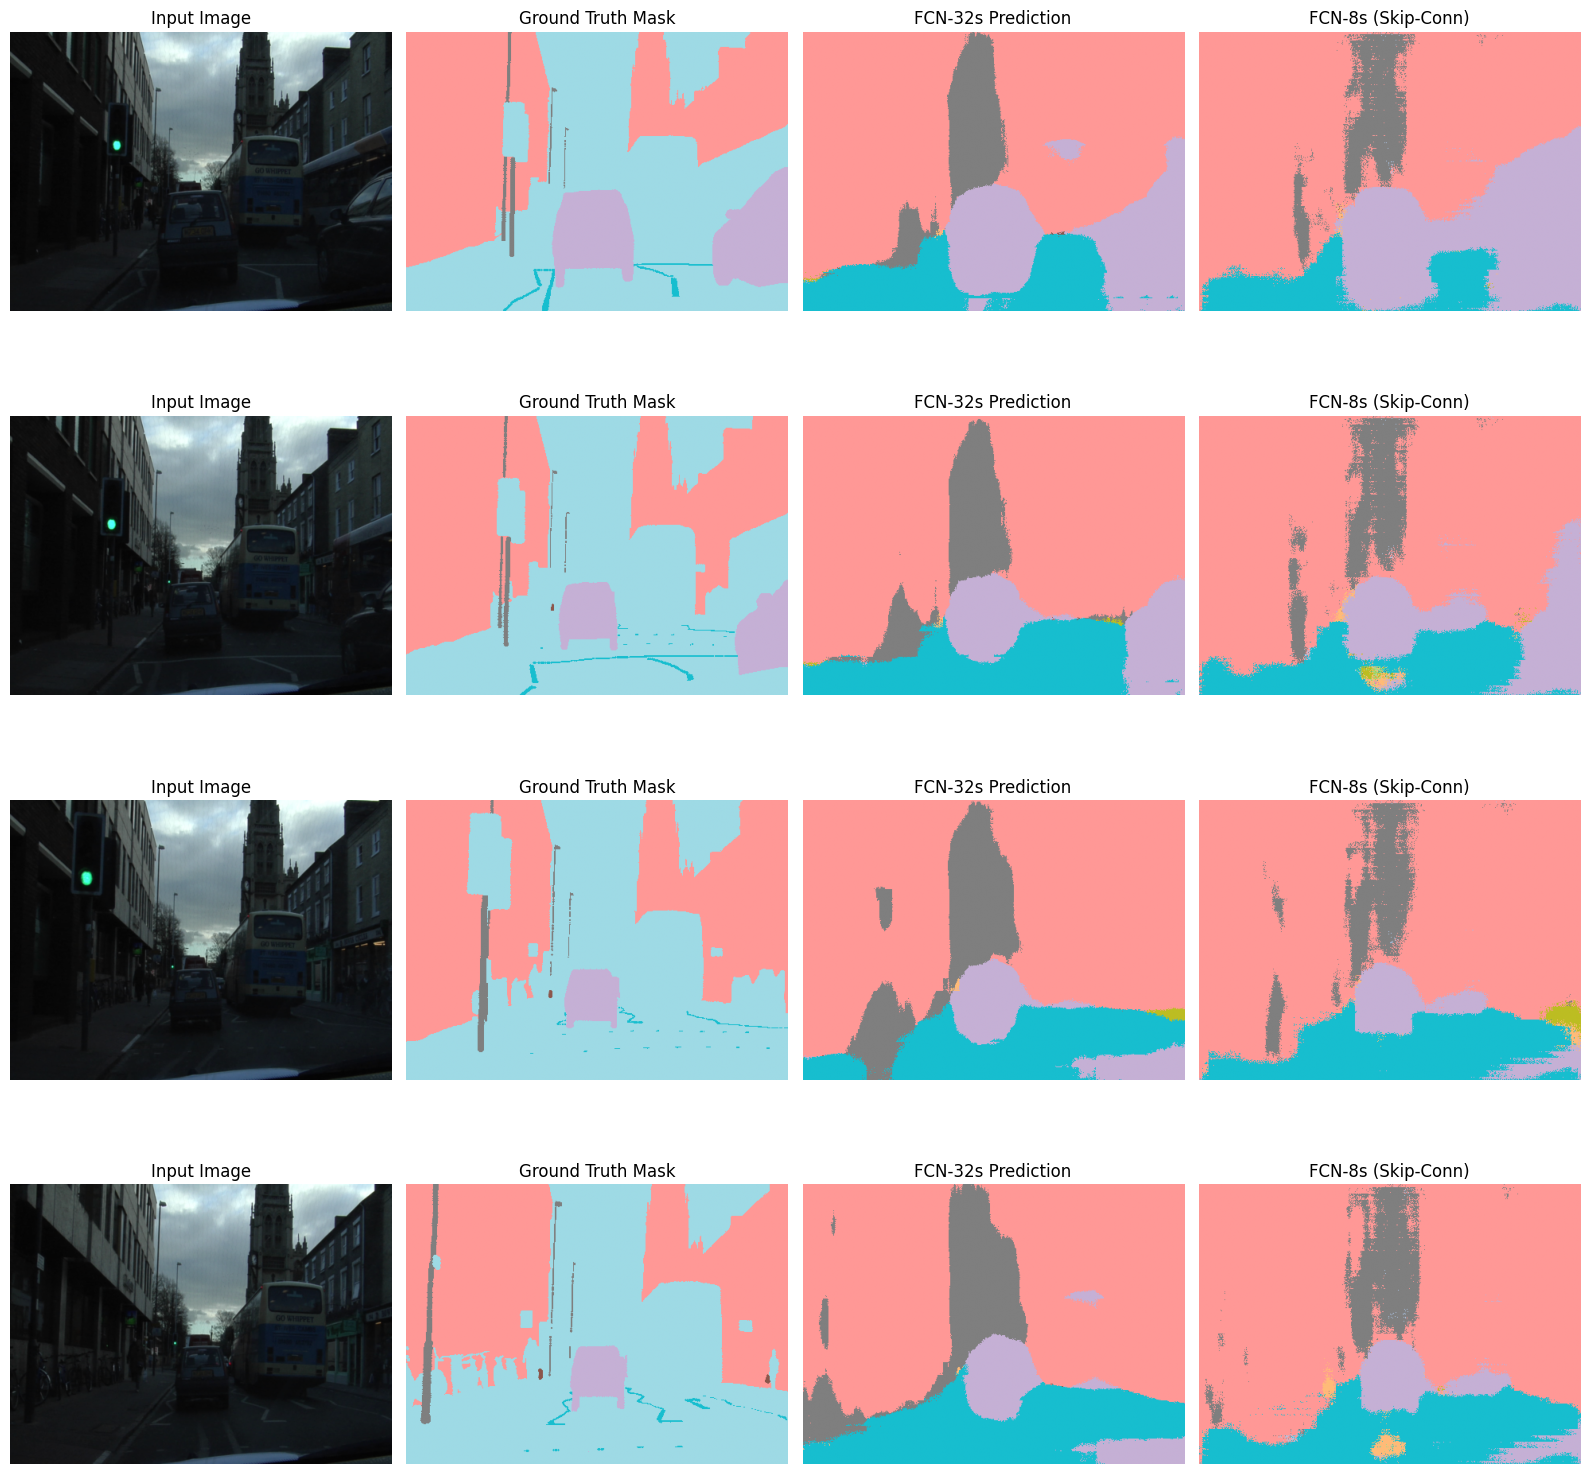

In [24]:
# Bảng so sánh định lượng
print("\n=== BẢNG SO SÁNH KẾT QUẢ ĐỊNH LƯỢNG ===")
print(f"{'Mô hình':<12} | {'Pixel Accuracy (%)':<20} | {'mIoU (%)':<10}")
print("-" * 50)
print(f"{'FCN-32s':<12} | {history_32s['val_pa'][-1]*100:<20.2f} | {history_32s['val_miou'][-1]*100:<10.2f}")
print(f"{'FCN-8s':<12} | {history_8s['val_pa'][-1]*100:<20.2f} | {history_8s['val_miou'][-1]*100:<10.2f}")

# Trực quan hóa định tính
model_fcn32s.eval()
model_fcn8s.eval()

inv_normalize = lambda img: img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)

val_iter = iter(val_loader)
images, masks = next(val_iter)
images_gpu = images.to(device)

with torch.no_grad():
    preds_32s = torch.argmax(model_fcn32s(images_gpu), dim=1).cpu().numpy()
    preds_8s = torch.argmax(model_fcn8s(images_gpu), dim=1).cpu().numpy()

num_samples = 4
fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))

for i in range(num_samples):
    # Gốc
    img_unnorm = inv_normalize(images[i]).permute(1, 2, 0).numpy().clip(0, 1)
    axes[i, 0].imshow(img_unnorm)
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis("off")

    # Ground Truth
    axes[i, 1].imshow(masks[i].numpy(), cmap='tab20', vmin=0, vmax=NUM_CLASSES)
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    # Dự đoán FCN-32s
    axes[i, 2].imshow(preds_32s[i], cmap='tab20', vmin=0, vmax=NUM_CLASSES)
    axes[i, 2].set_title(f"FCN-32s Prediction")
    axes[i, 2].axis("off")

    # Dự đoán FCN-8s
    axes[i, 3].imshow(preds_8s[i], cmap='tab20', vmin=0, vmax=NUM_CLASSES)
    axes[i, 3].set_title(f"FCN-8s (Skip-Conn)")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()